In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

data = {}
for sym in symbols:
    data[sym] = yf.download(sym, start="2018-01-01", end="2025-01-01")

print(data["AAPL"].head())

/tmp/ipykernel_2055/192627604.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[sym] = yf.download(sym, start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2055/192627604.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[sym] = yf.download(sym, start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2055/192627604.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[sym] = yf.download(sym, start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2055/192627604.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data[sym] = yf.download(sym, start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 co

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.304176  40.313537  39.602258  39.812835  102223600
2018-01-03  40.297153  40.839972  40.233983  40.367346  118071600
2018-01-04  40.484341  40.587289  40.262067  40.369693   89738400
2018-01-05  40.945251  41.031820  40.489005  40.580254   94640000
2018-01-08  40.793175  41.087979  40.694903  40.793175   82271200


In [2]:
for sym in symbols:
    df = data[sym]
    df["returns"] = df["Close"].pct_change()
    data[sym] = df.dropna()

In [3]:
for sym in symbols:
    df = data[sym]
    df["target"] = df["Close"].shift(-1)
    data[sym] = df.dropna()


In [4]:
from sklearn.metrics import mean_absolute_error

for sym in symbols:
    df = data[sym]
    mae = mean_absolute_error(df["target"], df["Close"])
    print(f"{sym} baseline MAE:", round(mae, 3))

AAPL baseline MAE: 1.571
MSFT baseline MAE: 2.891
GOOGL baseline MAE: 1.372
AMZN baseline MAE: 1.961
NVDA baseline MAE: 0.69


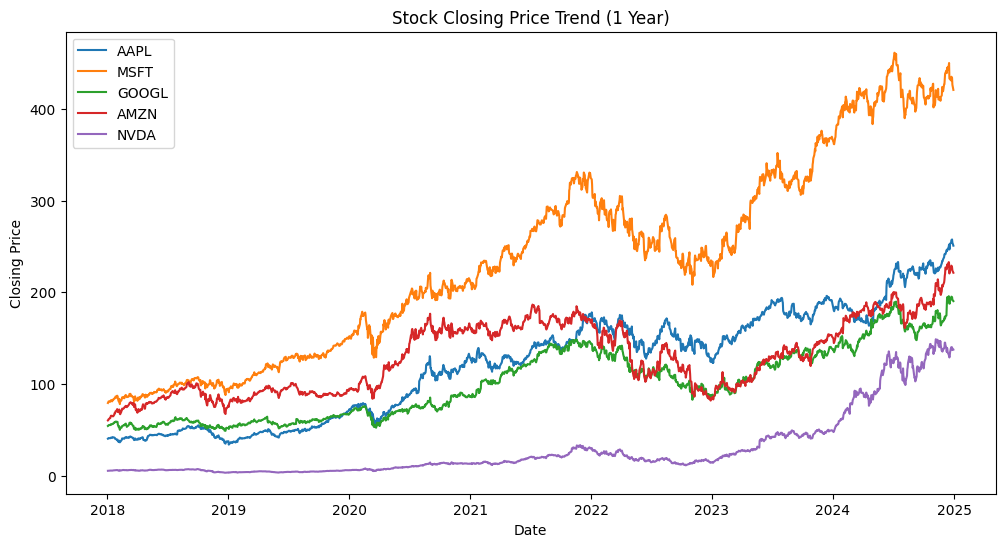

In [5]:
# Closing Price Trend (Time Series)

plt.figure(figsize=(12, 6))

for sym in symbols:
    plt.plot(data[sym].index, data[sym]["Close"], label=sym)

plt.title("Stock Closing Price Trend (1 Year)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

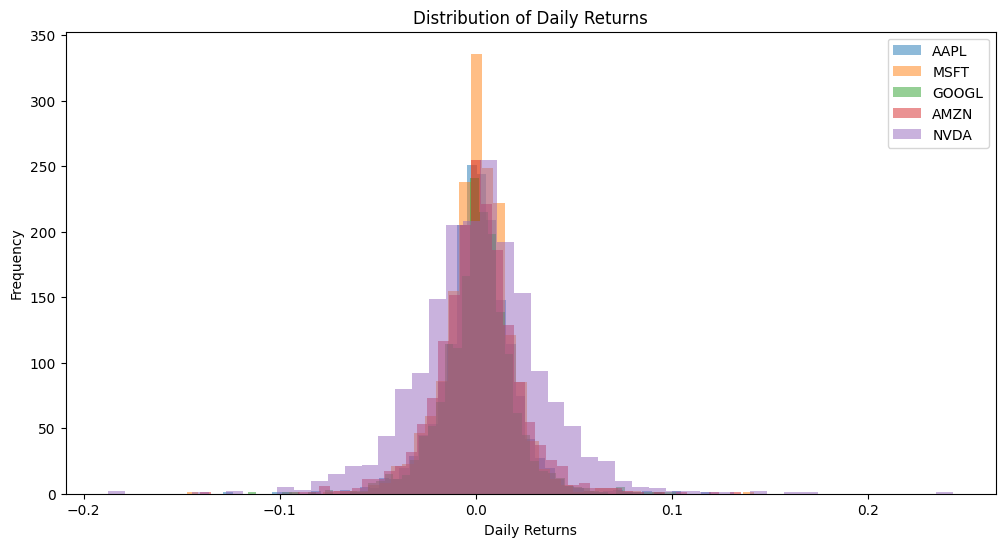

In [6]:
# Daily Returns Distribution (Risk Visualization)

plt.figure(figsize=(12, 6))

for sym in symbols:
    returns = data[sym]["Close"].pct_change()
    plt.hist(returns.dropna(), bins=50, alpha=0.5, label=sym)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

/tmp/ipykernel_2055/531149832.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  volatility.append(float(vol))
/tmp/ipykernel_2055/531149832.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  volatility.append(float(vol))
/tmp/ipykernel_2055/531149832.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  volatility.append(float(vol))
/tmp/ipykernel_2055/531149832.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  volatility.append(float(vol))
/tmp/ipykernel_2055/531149832.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use floa

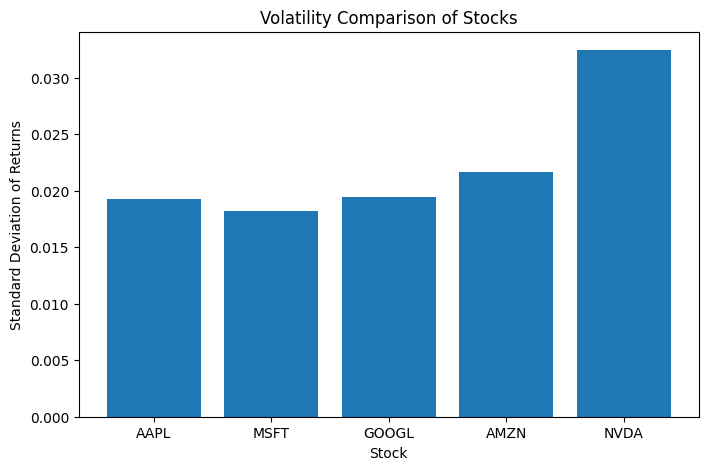

In [7]:
# Volatility Comparison (Bar Chart)

volatility = []

for sym in symbols:
    vol = data[sym]["Close"].pct_change().dropna().std()
    volatility.append(float(vol))

vol_df = pd.DataFrame({
    "Stock": symbols,
    "Volatility": volatility
})

plt.figure(figsize=(8, 5))
plt.bar(vol_df["Stock"].values, vol_df["Volatility"].values)
plt.title("Volatility Comparison of Stocks")
plt.xlabel("Stock")
plt.ylabel("Standard Deviation of Returns")
plt.show()

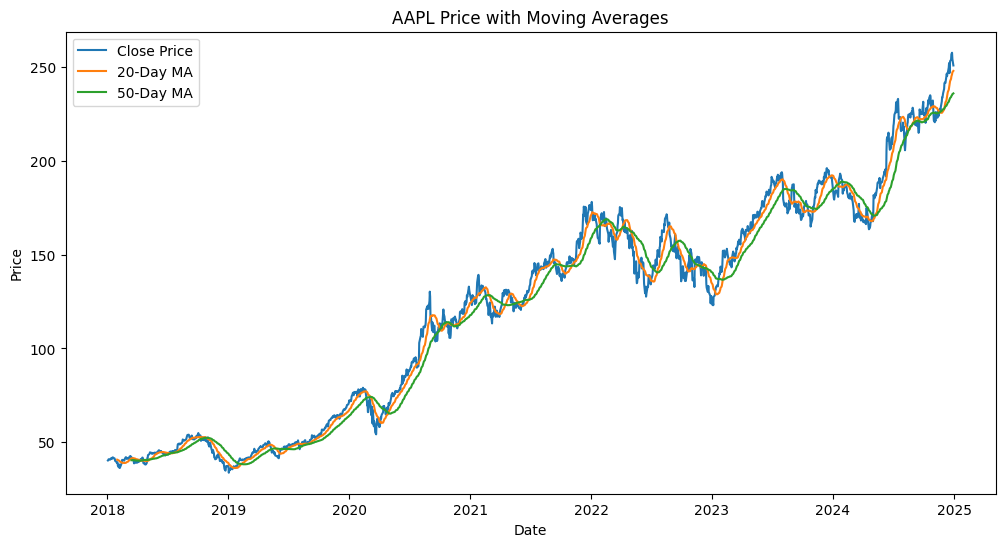

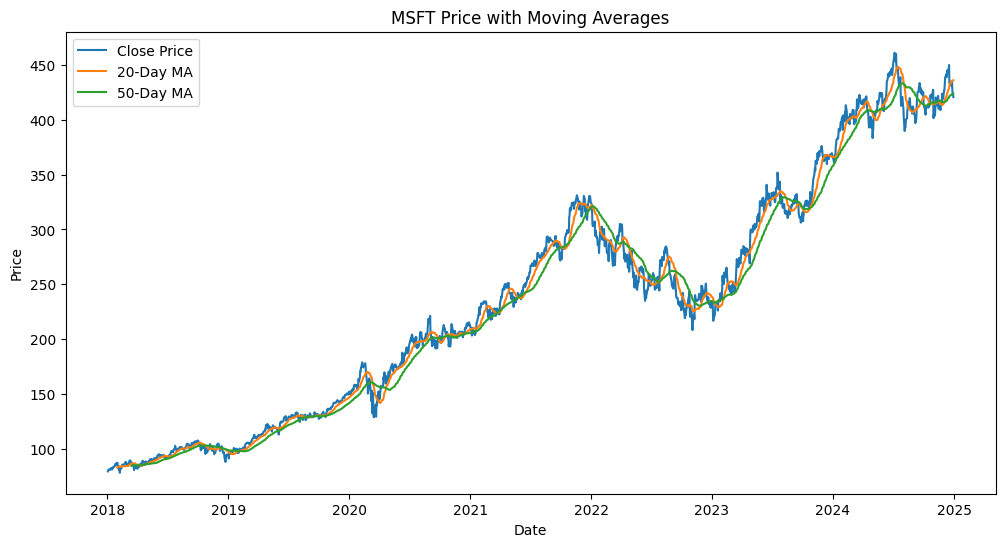

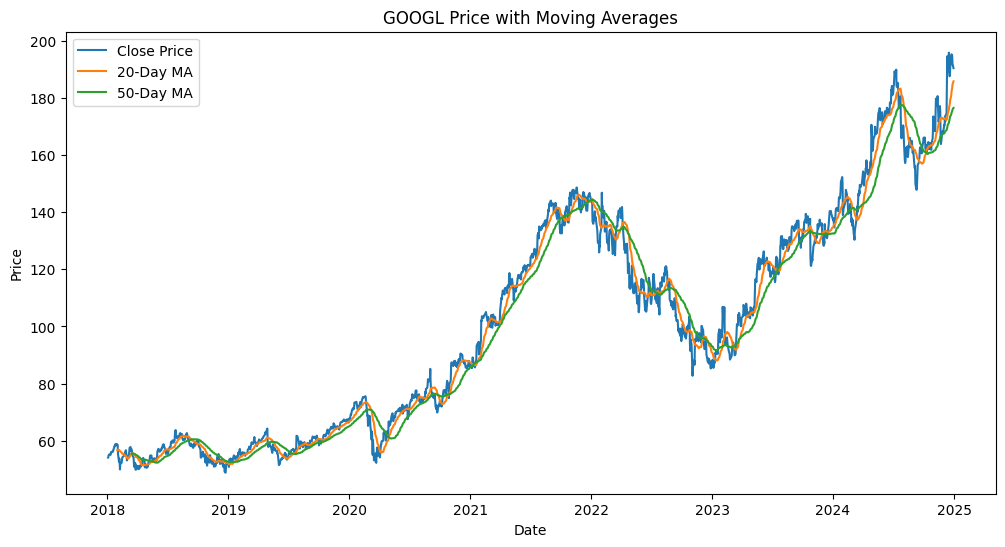

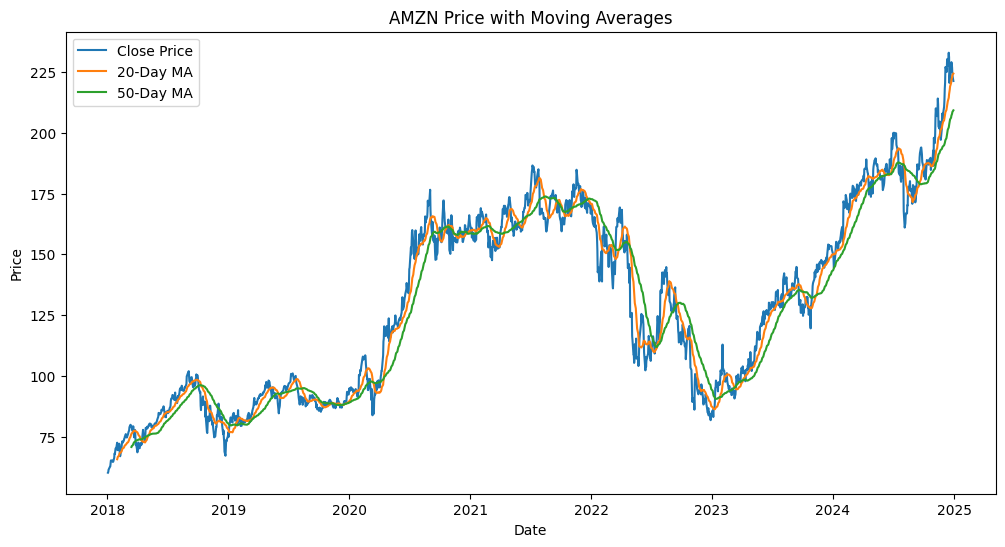

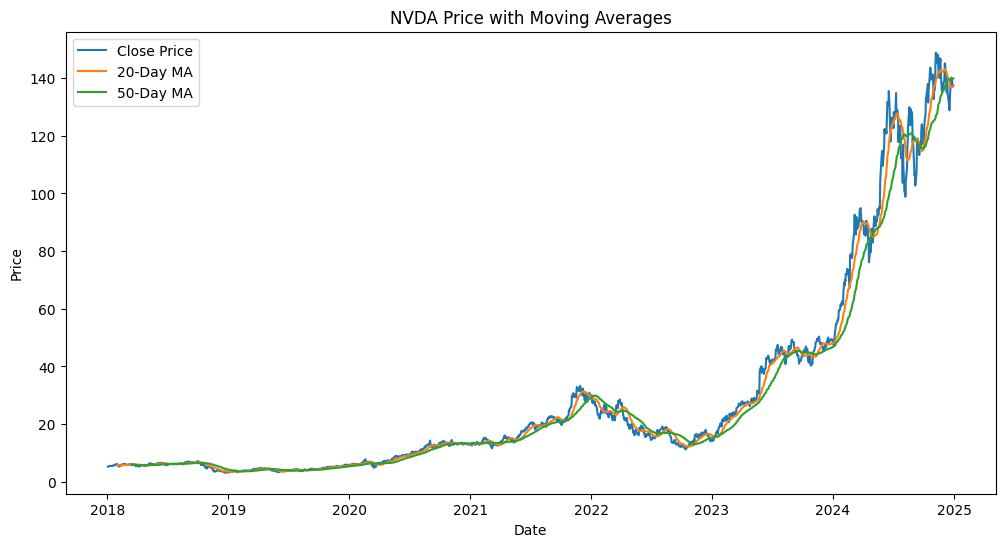

In [8]:
# Moving Averages (Trend Strength)

window_short = 20
window_long = 50

for sym in symbols:
    df = data[sym].copy()
    df["MA20"] = df["Close"].rolling(window_short).mean()
    df["MA50"] = df["Close"].rolling(window_long).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["Close"], label="Close Price")
    plt.plot(df.index, df["MA20"], label="20-Day MA")
    plt.plot(df.index, df["MA50"], label="50-Day MA")
    plt.title(f"{sym} Price with Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

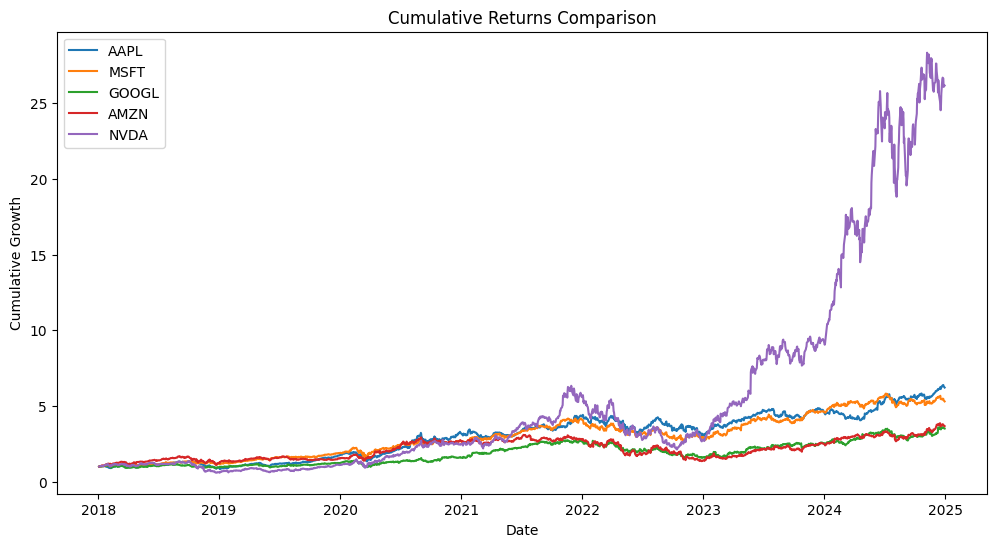

In [9]:
# Cumulative Returns (Performance Comparison)

plt.figure(figsize=(12, 6))

for sym in symbols:
    returns = data[sym]["Close"].pct_change()
    cumulative_returns = (1 + returns).cumprod()
    plt.plot(cumulative_returns, label=sym)

plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.show()

In [10]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

from statsmodels.tsa.arima.model import ARIMA

In [11]:
def create_sequences(series, window_size=60):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = math.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return mae, rmse, mape

In [12]:
window_size = 60

for sym in symbols:
    print(f"\n===== {sym} Deep Learning Models =====")

    df = data[sym]
    prices = df["Close"].values.reshape(-1, 1)

    # Scale
    scaler = MinMaxScaler()
    scaled_prices = scaler.fit_transform(prices)

    # Create sequences
    X, y = create_sequences(scaled_prices, window_size)

    # Time-series split (NO SHUFFLE)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # ---------------- LSTM ----------------
    lstm_model = Sequential([
        LSTM(50, input_shape=(window_size, 1)),
        Dense(1)
    ])

    lstm_model.compile(optimizer="adam", loss="mse")
    lstm_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

    lstm_pred_scaled = lstm_model.predict(X_test)
    lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
    y_test_actual = scaler.inverse_transform(y_test)

    lstm_mae, lstm_rmse, lstm_mape = evaluate(y_test_actual, lstm_pred)

    print("LSTM Results:")
    print(f"MAE  : {lstm_mae:.3f}")
    print(f"RMSE : {lstm_rmse:.3f}")
    print(f"MAPE : {lstm_mape:.2f}%")

    # ---------------- GRU ----------------
    gru_model = Sequential([
        GRU(50, input_shape=(window_size, 1)),
        Dense(1)
    ])

    gru_model.compile(optimizer="adam", loss="mse")
    gru_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

    gru_pred_scaled = gru_model.predict(X_test)
    gru_pred = scaler.inverse_transform(gru_pred_scaled)

    gru_mae, gru_rmse, gru_mape = evaluate(y_test_actual, gru_pred)

    print("\nGRU Results:")
    print(f"MAE  : {gru_mae:.3f}")
    print(f"RMSE : {gru_rmse:.3f}")
    print(f"MAPE : {gru_mape:.2f}%")


===== AAPL Deep Learning Models =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
LSTM Results:
MAE  : 5.921
RMSE : 7.252
MAPE : 2.93%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

GRU Results:
MAE  : 3.305
RMSE : 4.226
MAPE : 1.68%

===== MSFT Deep Learning Models =====


...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

GRU Results:
MAE  : 3.069
RMSE : 4.099
MAPE : 1.80%

===== NVDA Deep Learning Models =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
LSTM Results:
MAE  : 4.769
RMSE : 6.187
MAPE : 5.14%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

GRU Results:
MAE  : 3.120
RMSE : 4.279
MAPE : 3.37%


In [13]:
for sym in symbols:
    print(f"\n===== {sym} ARIMA Model =====")

    df = data[sym]
    prices = df["Close"].values

    split = int(len(prices) * 0.8)
    train, test = prices[:split], prices[split:]

    model = ARIMA(train, order=(5, 1, 0))
    fitted = model.fit()

    forecast = fitted.forecast(steps=len(test))

    mae, rmse, mape = evaluate(test, forecast)

    print("ARIMA Results:")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAPE : {mape:.2f}%")


===== AAPL ARIMA Model =====
ARIMA Results:
MAE  : 24.322
RMSE : 32.751
MAPE : 11.17%

===== MSFT ARIMA Model =====
ARIMA Results:
MAE  : 71.506
RMSE : 80.623
MAPE : 17.37%

===== GOOGL ARIMA Model =====
ARIMA Results:
MAE  : 24.244
RMSE : 30.348
MAPE : 14.55%

===== AMZN ARIMA Model =====
ARIMA Results:
MAE  : 32.549
RMSE : 39.102
MAPE : 17.61%

===== NVDA ARIMA Model =====
ARIMA Results:
MAE  : 45.177
RMSE : 57.406
MAPE : 40.36%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


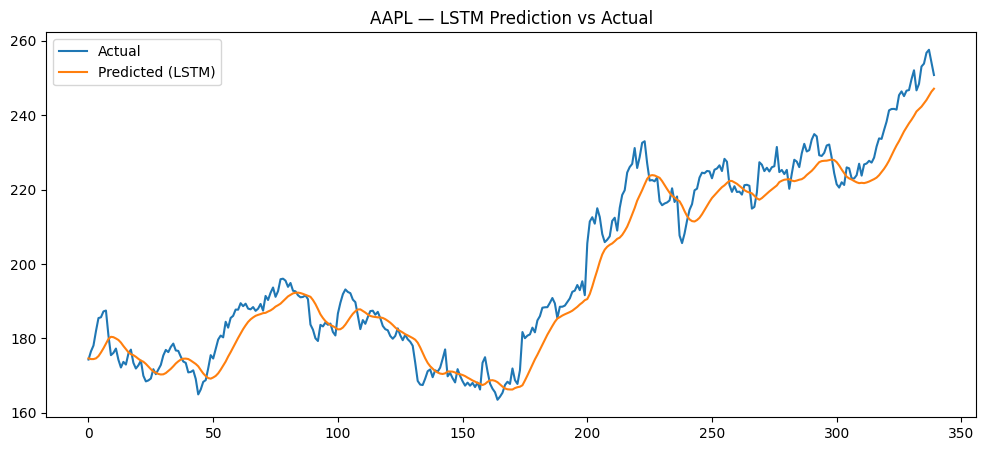

In [14]:
sym = "AAPL"

df = data[sym]
prices = df["Close"].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(prices)

X, y = create_sequences(scaled_prices, 60)
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(50, input_shape=(60, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted (LSTM)")
plt.title("AAPL — LSTM Prediction vs Actual")
plt.legend()
plt.show()

In [15]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

In [16]:
df["target"] = df["log_return"].shift(-1)
df = df.dropna()

In [17]:
df["volatility_14"] = df["log_return"].rolling(14).std()
df["volatility_30"] = df["log_return"].rolling(30).std()

/tmp/ipykernel_2055/2161758183.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["volatility_14"] = df["log_return"].rolling(14).std()
/tmp/ipykernel_2055/2161758183.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["volatility_30"] = df["log_return"].rolling(30).std()


In [18]:
df["momentum_10"] = df["Close"] - df["Close"].shift(10)
df["momentum_20"] = df["Close"] - df["Close"].shift(20)

/tmp/ipykernel_2055/1172583594.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["momentum_10"] = df["Close"] - df["Close"].shift(10)
/tmp/ipykernel_2055/1172583594.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["momentum_20"] = df["Close"] - df["Close"].shift(20)


In [19]:
df["ema_10"] = df["Close"].ewm(span=10).mean()
df["volume_change"] = df["Volume"].pct_change()

/tmp/ipykernel_2055/3659126944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ema_10"] = df["Close"].ewm(span=10).mean()
/tmp/ipykernel_2055/3659126944.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["volume_change"] = df["Volume"].pct_change()


In [20]:
df = df.dropna()

In [21]:
features = [
    "log_return",
    "volatility_14",
    "momentum_10",
    "ema_10",
    "volume_change"
]

X = df[features]
y = df["target"]

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

In [23]:
def create_sequences_multivariate(X, y, window_size=60):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences_multivariate(X_scaled, y_scaled, 60)

In [24]:
def split_data(X, y, ratio):
    split = int(len(X)*ratio)
    return X[:split], X[split:], y[:split], y[split:]

# Example 80-20
X_train, X_test, y_train, y_test = split_data(X_seq, y_seq, 0.8)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_lstm(input_shape):
    model = Sequential()

    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))

    model.add(LSTM(64))
    model.add(Dropout(0.3))

    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return model

In [26]:
model = build_lstm((60, len(features)))

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0306 - val_loss: 0.0052
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0121 - val_loss: 0.0044
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0113 - val_loss: 0.0043
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0104 - val_loss: 0.0032
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0100 - val_loss: 0.0031
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0094 - val_loss: 0.0030
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0099 - val_loss: 0.0039
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0098 - val_loss: 0.0035
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0094 - val_loss: 0.0031
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0092 - val_loss: 0.0030
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0091 - val_loss: 0.0032
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.

In [27]:
from tensorflow.keras.layers import GRU

def build_gru(input_shape):
    model = Sequential()

    model.add(GRU(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))

    model.add(GRU(64))
    model.add(Dropout(0.3))

    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return model

In [28]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


In [29]:
last_train_price = df["Close"].iloc[len(X_train) + 59]

predicted_prices = []
price = last_train_price

for r in y_pred.flatten():
    price = price * np.exp(r)
    predicted_prices.append(price)

In [30]:
from statsmodels.tsa.arima.model import ARIMA

train_size = int(len(df)*0.8)
train = df["log_return"][:train_size]
test = df["log_return"][train_size:]

model = ARIMA(train, order=(5,0,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

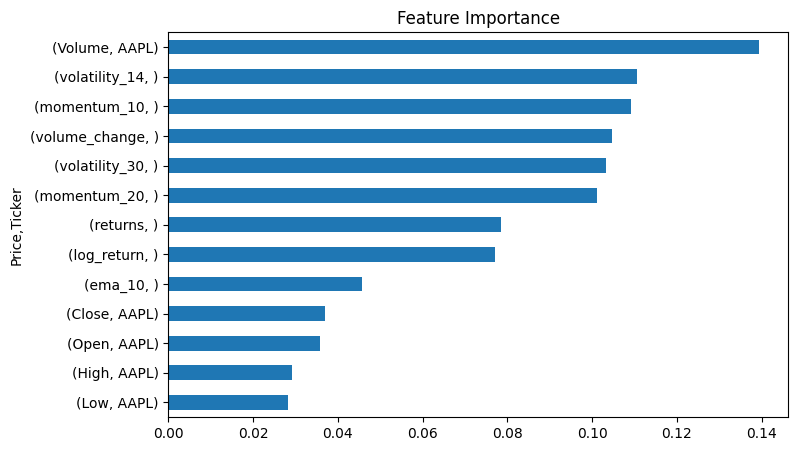

In [32]:
from sklearn.ensemble import RandomForestRegressor

# Drop target NaNs
df_model = df.dropna()

X = df_model.drop(columns=["target"])
y = df_model["target"]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values()

feat_imp.plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

Shape after dropna: (1728, 14)


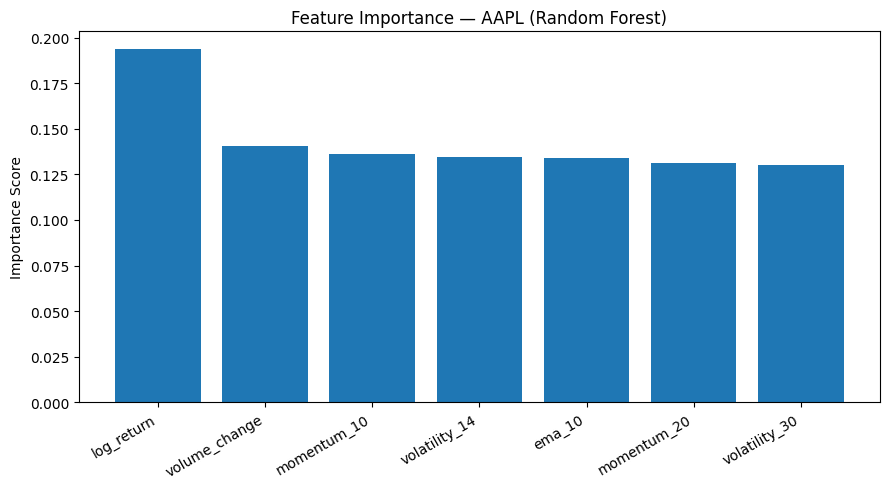

Feature Importances:
  log_return           0.1937
  volume_change        0.1407
  momentum_10          0.1362
  volatility_14        0.1347
  ema_10               0.1337
  momentum_20          0.1311
  volatility_30        0.1299


In [51]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

sym = 'AAPL'
df_fi = data[sym].copy()

# Fix MultiIndex columns from yfinance
df_fi.columns = df_fi.columns.get_level_values(0)

close = df_fi['Close'].squeeze()

# Reconstruct engineered features
df_fi['log_return']     = np.log(close / close.shift(1))
df_fi['volatility_14']  = df_fi['log_return'].rolling(14).std()
df_fi['volatility_30']  = df_fi['log_return'].rolling(30).std()
df_fi['momentum_10']    = close - close.shift(10)
df_fi['momentum_20']    = close - close.shift(20)
df_fi['ema_10']         = close.ewm(span=10).mean()
df_fi['volume_change']  = df_fi['Volume'].squeeze().pct_change()
df_fi['target']         = df_fi['log_return'].shift(-1)
df_fi = df_fi.dropna()

print(f"Shape after dropna: {df_fi.shape}")

feature_cols = ['log_return', 'volatility_14', 'volatility_30',
                'momentum_10', 'momentum_20', 'ema_10', 'volume_change']

X_fi = df_fi[feature_cols]
y_fi = df_fi['target']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_fi, y_fi)

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(feature_cols)), importances[idx])
plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in idx], rotation=30, ha='right')
plt.title(f'Feature Importance — {sym} (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('Feature Importances:')
for i in idx:
    print(f'  {feature_cols[i]:<20} {importances[i]:.4f}')

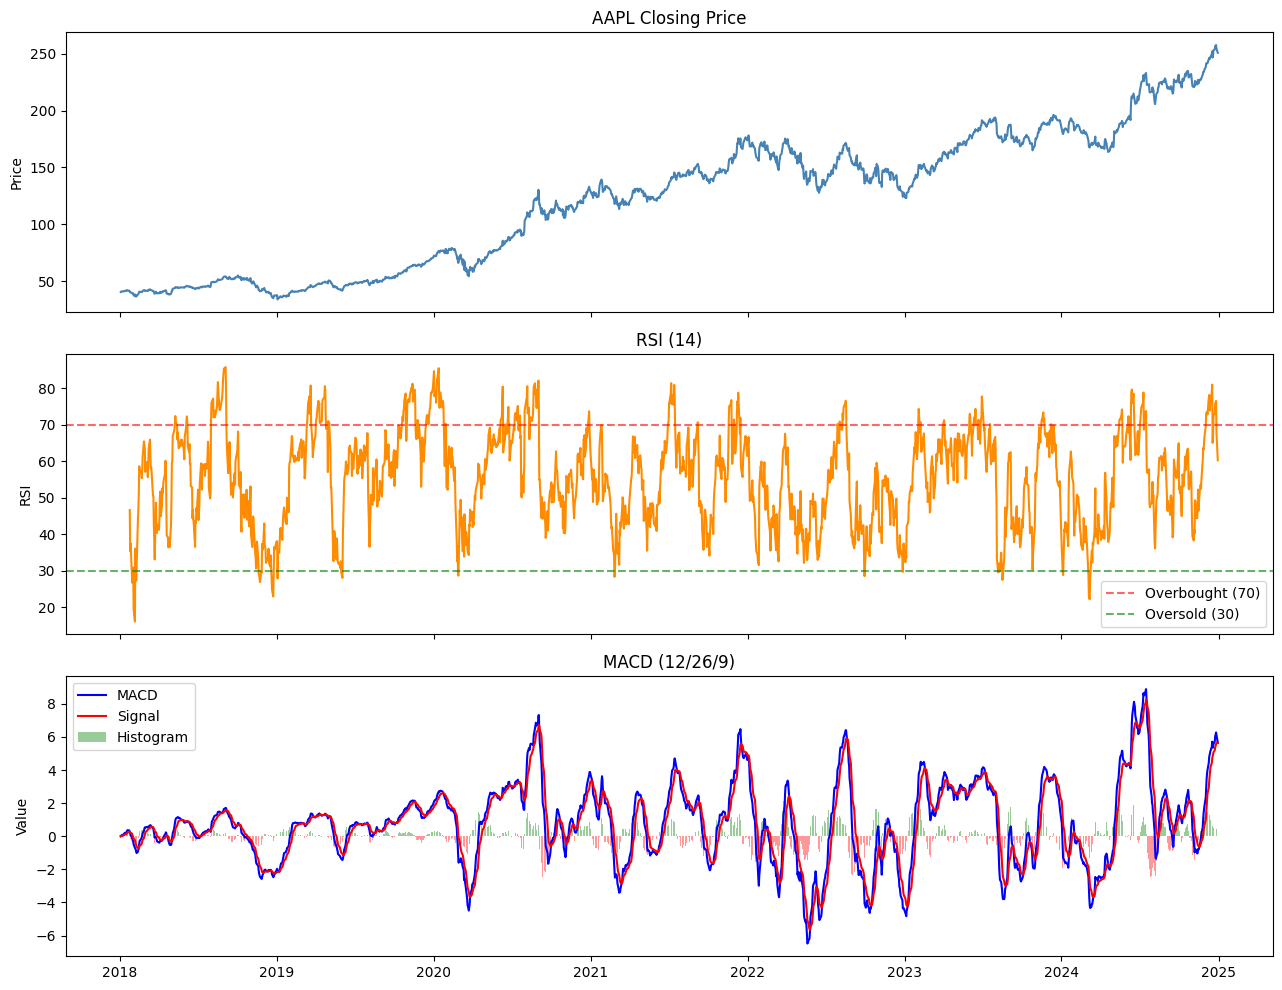

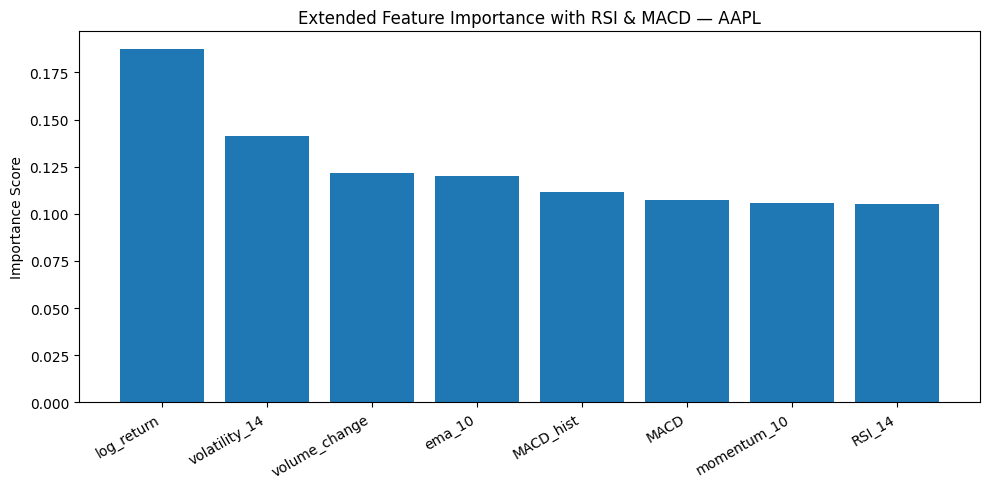

Extended Feature Importances:
  log_return           0.1875
  volatility_14        0.1414
  volume_change        0.1214
  ema_10               0.1198
  MACD_hist            0.1115
  MACD                 0.1074
  momentum_10          0.1056
  RSI_14               0.1054


In [52]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast    = series.ewm(span=fast, adjust=False).mean()
    ema_slow    = series.ewm(span=slow, adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram

sym = 'AAPL'
df_ind = data[sym].copy()
close = df_ind['Close'].squeeze()

df_ind['RSI_14'] = compute_rsi(close, 14)
df_ind['MACD'], df_ind['MACD_signal'], df_ind['MACD_hist'] = compute_macd(close)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(df_ind.index, close, color='steelblue')
axes[0].set_title(f'{sym} Closing Price')
axes[0].set_ylabel('Price')

axes[1].plot(df_ind.index, df_ind['RSI_14'], color='darkorange')
axes[1].axhline(70, linestyle='--', color='red', alpha=0.6, label='Overbought (70)')
axes[1].axhline(30, linestyle='--', color='green', alpha=0.6, label='Oversold (30)')
axes[1].set_title('RSI (14)')
axes[1].set_ylabel('RSI')
axes[1].legend()

axes[2].plot(df_ind.index, df_ind['MACD'], label='MACD', color='blue')
axes[2].plot(df_ind.index, df_ind['MACD_signal'], label='Signal', color='red')
axes[2].bar(df_ind.index, df_ind['MACD_hist'], label='Histogram',
            color=df_ind['MACD_hist'].apply(lambda x: 'green' if x >= 0 else 'red'),
            alpha=0.4, width=1)
axes[2].set_title('MACD (12/26/9)')
axes[2].set_ylabel('Value')
axes[2].legend()

plt.tight_layout()
plt.show()

# Re-evaluate feature importance with RSI + MACD added
df_ind['log_return']    = np.log(close / close.shift(1))
df_ind['volatility_14'] = df_ind['log_return'].rolling(14).std()
df_ind['momentum_10']   = close - close.shift(10)
df_ind['ema_10']        = close.ewm(span=10).mean()
df_ind['volume_change'] = df_ind['Volume'].pct_change()
df_ind['target']        = df_ind['log_return'].shift(-1)
df_ind = df_ind.dropna()

ext_features = ['log_return', 'volatility_14', 'momentum_10',
                'ema_10', 'volume_change', 'RSI_14', 'MACD', 'MACD_hist']

X_ext = df_ind[ext_features]
y_ext = df_ind['target']

rf2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf2.fit(X_ext, y_ext)
imp2 = rf2.feature_importances_
idx2 = np.argsort(imp2)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(ext_features)), imp2[idx2])
plt.xticks(range(len(ext_features)), [ext_features[i] for i in idx2], rotation=30, ha='right')
plt.title(f'Extended Feature Importance with RSI & MACD — {sym}')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('Extended Feature Importances:')
for i in idx2:
    print(f'  {ext_features[i]:<20} {imp2[i]:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Window=60: MAE=0.01088  RMSE=0.01448  MAPE=39571.9792%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Window=90: MAE=0.01144  RMSE=0.01492  MAPE=82841.6357%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Window=120: MAE=0.01024  RMSE=0.01369  MAPE=10921.1426%

Summary Table:
 Window     MAE    RMSE       MAPE
     60 0.01088 0.01448 39571.9792
     90 0.01144 0.01492 82841.6357
    120 0.01024 0.01369 10921.1426


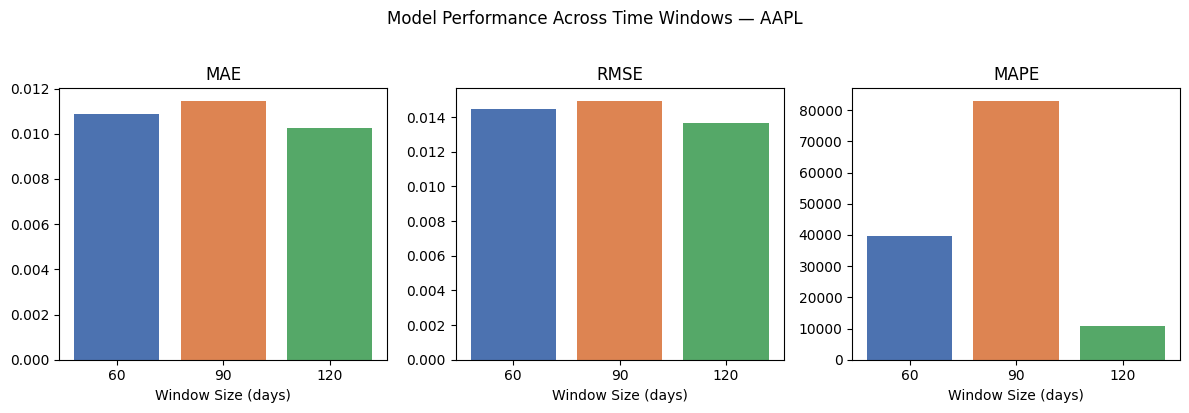

In [53]:
# Validates model evaluation using 60-day / 90-day / 120-day windows
# ──────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import math, pandas as pd

sym = 'AAPL'
df_tw = df_ind.copy()

feat_tw = ['log_return', 'volatility_14', 'momentum_10',
           'ema_10', 'volume_change', 'RSI_14', 'MACD']
X_tw_raw = df_tw[feat_tw].values
y_tw_raw = df_tw['target'].values.reshape(-1, 1)

scaler_Xtw = MinMaxScaler()
scaler_ytw = MinMaxScaler()
X_tw_sc = scaler_Xtw.fit_transform(X_tw_raw)
y_tw_sc = scaler_ytw.fit_transform(y_tw_raw)

results_tw = []

for window in [60, 90, 120]:
    Xs, ys = [], []
    for i in range(window, len(X_tw_sc)):
        Xs.append(X_tw_sc[i-window:i])
        ys.append(y_tw_sc[i])
    Xs, ys = np.array(Xs), np.array(ys)

    split = int(len(Xs) * 0.8)
    Xtr, Xte = Xs[:split], Xs[split:]
    ytr, yte = ys[:split], ys[split:]

    m = Sequential([
        LSTM(32, input_shape=(window, len(feat_tw))),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    m.fit(Xtr, ytr, epochs=10, batch_size=32, verbose=0)

    pred_sc = m.predict(Xte, verbose=0)
    pred    = scaler_ytw.inverse_transform(pred_sc)
    true    = scaler_ytw.inverse_transform(yte)

    mae  = mean_absolute_error(true, pred)
    rmse = math.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-8))) * 100
    results_tw.append({'Window': window, 'MAE': round(mae, 5),
                       'RMSE': round(rmse, 5), 'MAPE': round(mape, 4)})
    print(f'Window={window}: MAE={mae:.5f}  RMSE={rmse:.5f}  MAPE={mape:.4f}%')

res_df = pd.DataFrame(results_tw)
print('\nSummary Table:')
print(res_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(res_df['Window'].astype(str), res_df[col], color=['#4c72b0','#dd8452','#55a868'])
    ax.set_title(col)
    ax.set_xlabel('Window Size (days)')
plt.suptitle(f'Model Performance Across Time Windows — {sym}', y=1.02)
plt.tight_layout()
plt.show()

Training Baseline LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Regularized LSTM (Dropout + EarlyStopping)...

Baseline    — MAE: 0.01100  RMSE: 0.01438  MAPE: 112407.8627%
Regularized — MAE: 0.01016  RMSE: 0.01374  MAPE: 56375.3980%
(EarlyStopping stopped at epoch 14)


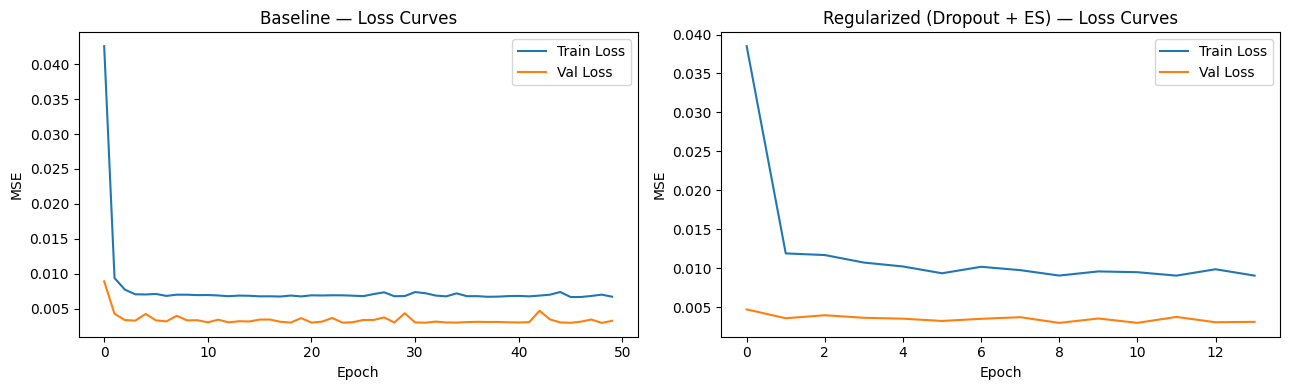

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np, math
import matplotlib.pyplot as plt

sym = 'AAPL'
df_s = df_ind.copy()

feat_s = ['log_return', 'volatility_14', 'momentum_10',
          'ema_10', 'volume_change', 'RSI_14', 'MACD']
X_s_raw = df_s[feat_s].values
y_s_raw = df_s['target'].values.reshape(-1, 1)

sc_X = MinMaxScaler(); sc_y = MinMaxScaler()
X_s_sc = sc_X.fit_transform(X_s_raw)
y_s_sc = sc_y.fit_transform(y_s_raw)

WINDOW = 60
Xs, ys = [], []
for i in range(WINDOW, len(X_s_sc)):
    Xs.append(X_s_sc[i-WINDOW:i])
    ys.append(y_s_sc[i])
Xs, ys = np.array(Xs), np.array(ys)

split = int(len(Xs) * 0.8)
Xtr, Xte = Xs[:split], Xs[split:]
ytr, yte = ys[:split], ys[split:]

shape = (WINDOW, len(feat_s))

def eval_model(true_sc, pred_sc):
    true = sc_y.inverse_transform(true_sc)
    pred = sc_y.inverse_transform(pred_sc)
    mae  = mean_absolute_error(true, pred)
    rmse = math.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-8))) * 100
    return mae, rmse, mape

def build_baseline(input_shape):
    m = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

def build_regularized(input_shape):
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print('Training Baseline LSTM...')
base_model = build_baseline(shape)
h_base = base_model.fit(Xtr, ytr, epochs=50, batch_size=32,
                        validation_data=(Xte, yte), verbose=0)

print('Training Regularized LSTM (Dropout + EarlyStopping)...')
reg_model = build_regularized(shape)
h_reg = reg_model.fit(Xtr, ytr, epochs=50, batch_size=32,
                      validation_data=(Xte, yte),
                      callbacks=[es], verbose=0)

mae_b, rmse_b, mape_b = eval_model(yte, base_model.predict(Xte, verbose=0))
mae_r, rmse_r, mape_r = eval_model(yte, reg_model.predict(Xte, verbose=0))

print(f'\nBaseline    — MAE: {mae_b:.5f}  RMSE: {rmse_b:.5f}  MAPE: {mape_b:.4f}%')
print(f'Regularized — MAE: {mae_r:.5f}  RMSE: {rmse_r:.5f}  MAPE: {mape_r:.4f}%')
print(f'(EarlyStopping stopped at epoch {len(h_reg.history["loss"])})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, h, title in zip(axes, [h_base, h_reg], ['Baseline', 'Regularized (Dropout + ES)']):
    ax.plot(h.history['loss'],     label='Train Loss')
    ax.plot(h.history['val_loss'], label='Val Loss')
    ax.set_title(f'{title} — Loss Curves')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend()
plt.tight_layout()
plt.show()

Training Stacked LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  MAE=0.01003  RMSE=0.01359  MAPE=3364.5641%
Training LSTM-GRU Hybrid...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  MAE=0.01003  RMSE=0.01361  MAPE=45649.3888%
Training Bidirectional LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  MAE=0.01013  RMSE=0.01374  MAPE=6212.0002%

Architecture Comparison:
                         MAE      RMSE          MAPE
Stacked LSTM        0.010030  0.013588   3364.564126
LSTM-GRU Hybrid     0.010027  0.013614  45649.388792
Bidirectional LSTM  0.010129  0.013738   6212.000167


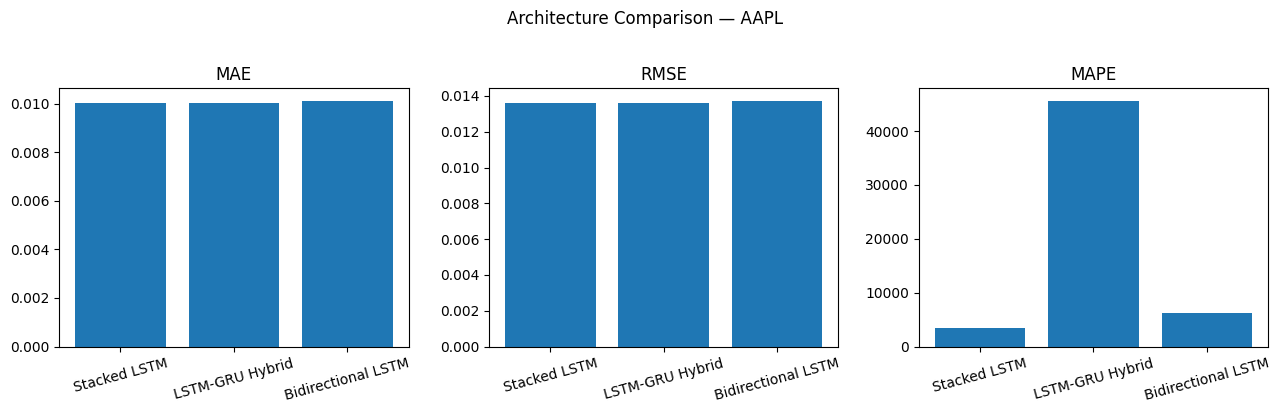

In [55]:
from tensorflow.keras.layers import GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

def build_stacked_lstm(input_shape):
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

def build_lstm_gru(input_shape):
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(64),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

def build_bidirectional(input_shape):
    m = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.2),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

arch_results = {}
builders = {
    'Stacked LSTM':       build_stacked_lstm,
    'LSTM-GRU Hybrid':    build_lstm_gru,
    'Bidirectional LSTM': build_bidirectional,
}

for name, builder in builders.items():
    print(f'Training {name}...')
    m = builder(shape)
    m.fit(Xtr, ytr, epochs=50, batch_size=32,
          validation_data=(Xte, yte),
          callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
          verbose=0)
    mae_a, rmse_a, mape_a = eval_model(yte, m.predict(Xte, verbose=0))
    arch_results[name] = {'MAE': mae_a, 'RMSE': rmse_a, 'MAPE': mape_a}
    print(f'  MAE={mae_a:.5f}  RMSE={rmse_a:.5f}  MAPE={mape_a:.4f}%')

arch_df = pd.DataFrame(arch_results).T
print('\nArchitecture Comparison:')
print(arch_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(arch_df.index, arch_df[metric])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Architecture Comparison — AAPL', y=1.02)
plt.tight_layout()
plt.show()

Rolling forecast: init=1178, step=20, total test=506


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Window 1178→1198 trained.
  Window 1198→1218 trained.


  Window 1218→1238 trained.


  Window 1238→1258 trained.
  Window 1258→1278 trained.
  Window 1278→1298 trained.
  Window 1298→1318 trained.
  Window 1318→1338 trained.
  Window 1338→1358 trained.
  Window 1358→1378 trained.
  Window 1378→1398 trained.
  Window 1398→1418 trained.
  Window 1418→1438 trained.
  Window 1438→1458 trained.
  Window 1458→1478 trained.
  Window 1478→1498 trained.
  Window 1498→1518 trained.
  Window 1518→1538 trained.
  Window 1538→1558 trained.
  Window 1558→1578 trained.
  Window 1578→1598 trained.
  Window 1598→1618 trained.
  Window 1618→1638 trained.
  Window 1638→1658 trained.
  Window 1658→1678 trained.
  Window 1678→1683 trained.

Rolling Forecast — MAE: 0.01069  RMSE: 0.01449  MAPE: 174630.6369%


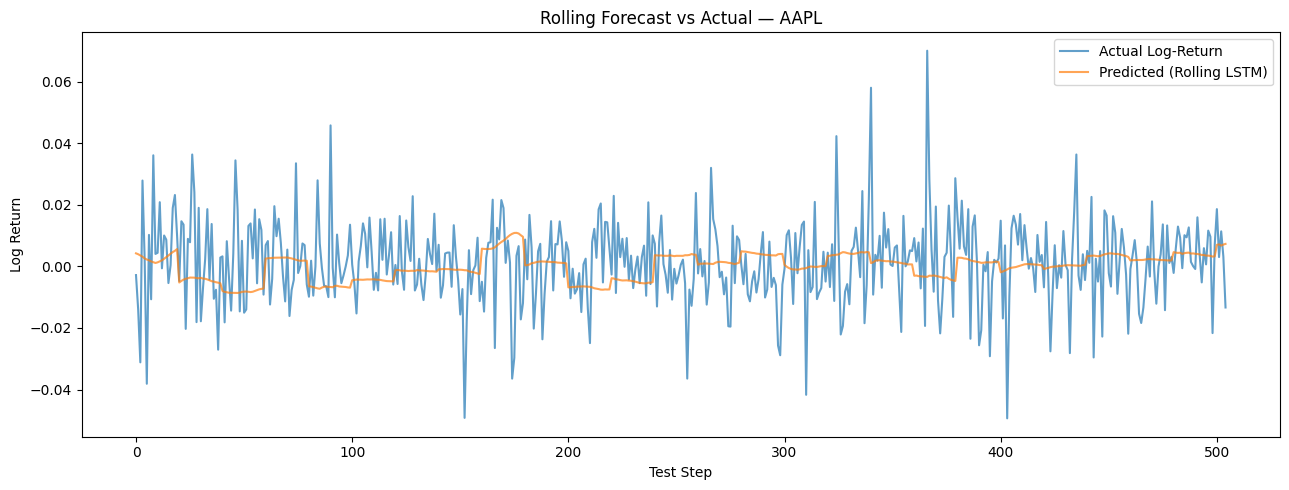

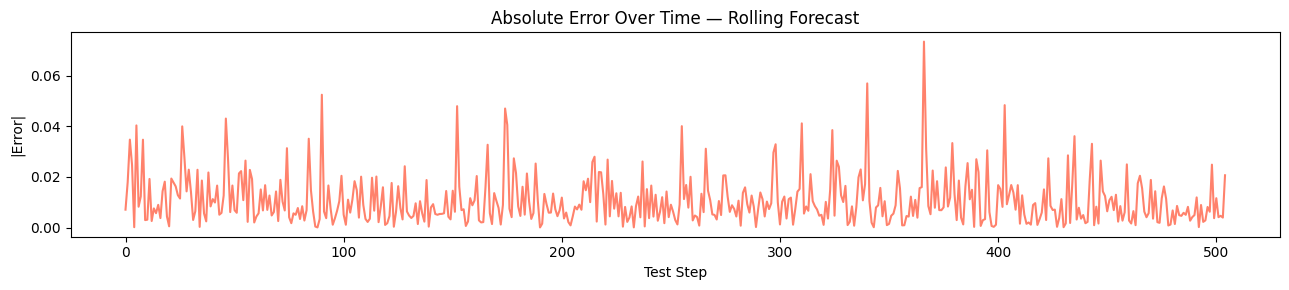

In [56]:
ROLL_INIT  = int(len(Xs) * 0.7)
ROLL_STEP  = 20
ROLL_AHEAD = 1

roll_preds = []
roll_trues = []

print(f'Rolling forecast: init={ROLL_INIT}, step={ROLL_STEP}, total test={len(Xs)-ROLL_INIT}')

for start in range(ROLL_INIT, len(Xs) - ROLL_AHEAD, ROLL_STEP):
    end = min(start + ROLL_STEP, len(Xs) - ROLL_AHEAD)

    Xtr_r = Xs[:start];   ytr_r = ys[:start]
    Xte_r = Xs[start:end]; yte_r = ys[start:end]

    roll_m = Sequential([
        LSTM(64, return_sequences=True, input_shape=shape),
        Dropout(0.3),
        LSTM(32),
        Dense(1)
    ])
    roll_m.compile(optimizer=Adam(1e-3), loss='mse')
    roll_m.fit(Xtr_r, ytr_r, epochs=10, batch_size=32, verbose=0)

    p = roll_m.predict(Xte_r, verbose=0)
    roll_preds.append(p)
    roll_trues.append(yte_r)
    print(f'  Window {start}→{end} trained.')

roll_preds = np.vstack(roll_preds)
roll_trues = np.vstack(roll_trues)

pred_actual = sc_y.inverse_transform(roll_preds)
true_actual = sc_y.inverse_transform(roll_trues)

r_mae  = mean_absolute_error(true_actual, pred_actual)
r_rmse = math.sqrt(mean_squared_error(true_actual, pred_actual))
r_mape = np.mean(np.abs((true_actual - pred_actual) / (true_actual + 1e-8))) * 100

print(f'\nRolling Forecast — MAE: {r_mae:.5f}  RMSE: {r_rmse:.5f}  MAPE: {r_mape:.4f}%')

plt.figure(figsize=(13, 5))
plt.plot(true_actual, label='Actual Log-Return', alpha=0.7)
plt.plot(pred_actual, label='Predicted (Rolling LSTM)', alpha=0.7)
plt.title('Rolling Forecast vs Actual — AAPL')
plt.xlabel('Test Step'); plt.ylabel('Log Return')
plt.legend(); plt.tight_layout(); plt.show()

errors = np.abs(true_actual.flatten() - pred_actual.flatten())
plt.figure(figsize=(13, 3))
plt.plot(errors, color='tomato', alpha=0.8)
plt.title('Absolute Error Over Time — Rolling Forecast')
plt.xlabel('Test Step'); plt.ylabel('|Error|')
plt.tight_layout(); plt.show()